In [2]:
import pandas as pd                        # to load and work with our CSV file
import numpy as np                         
import matplotlib.pyplot as plt            
import seaborn as sns


In [3]:
!pip install -r requirement.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirement.txt'


In [4]:
from sklearn.model_selection import train_test_split   # to split data into train/test
from sklearn.preprocessing import StandardScaler       # to normalize our number columns



# Step 1 - Data Preprocessing

In [5]:
# Loading the dataset

df = pd.read_csv("insurance.csv")

In [6]:
# total no of rows
df.shape[0]  


1338

In [7]:
# total no of column
df.shape[1]

7

In [8]:
print(f"Rows: {df.shape[0]}")    
print(f"Columns: {df.shape[1]}")  

Rows: 1338
Columns: 7


In [9]:

df.head()  

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:

print("Column Data Types")
print(df.dtypes)
# age → int, bmi/charges → float, sex/smoker/region → object (text)




Column Data Types
age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object


In [11]:
print("\n Missing Values ")
print(df.isnull().sum())



 Missing Values 
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


In [12]:
print("Basic Statistics")
df.describe()

Basic Statistics


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
# what unique text values exist in each category

print("sex      :", df['sex'].unique())
# → ['female' 'male']

print()

print("smoker   :", df['smoker'].unique())
# → ['yes' 'no']

print()

print("region   :", df['region'].unique())
# → ['southwest' 'southeast' 'northwest' 'northeast']



sex      : ['female' 'male']

smoker   : ['yes' 'no']

region   : ['southwest' 'southeast' 'northwest' 'northeast']


In [14]:
print("\n--- Value Counts ---")
print("Smoker breakdown:")
print(df['smoker'].value_counts())


print("\nRegion breakdown:")
print(df['region'].value_counts())


--- Value Counts ---
Smoker breakdown:
smoker
no     1064
yes     274
Name: count, dtype: int64

Region breakdown:
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64


# One hot encoding 
Converting text → numbers using One-Hot Encoding

Before encoding, our df has: sex, smoker, region as text

After encoding, they become 0s and 1s

In [15]:

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], 
                             drop_first=True, dtype=int)

# drop_first=True means:
#   sex     → keeps only 'sex_male'       (0=female, 1=male)
#   smoker  → keeps only 'smoker_yes'     (0=no, 1=yes)
#   region  → keeps 3 of the 4 regions    (the 4th is implied)

print("Columns after encoding:")
for col in df_encoded.columns:
    print("  →", col)



Columns after encoding:
  → age
  → bmi
  → children
  → charges
  → sex_male
  → smoker_yes
  → region_northwest
  → region_southeast
  → region_southwest


In [16]:
print(f"\nShape now: {df_encoded.shape}")   



Shape now: (1338, 9)


In [17]:
df_encoded.head()

,age,bmi,children,charges,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,16884.92400,0,1,0,0,1
1,18,33.770,1,1725.55230,1,0,0,1,0
2,28,33.000,3,4449.46200,1,0,0,1,0
3,33,22.705,0,21984.47061,1,0,1,0,0
4,32,28.880,0,3866.85520,1,0,1,0,0


In [18]:
# Separating what the model learns FROM vs what it PREDICTS

X = df_encoded.drop(columns=['charges'])   # all columns EXCEPT charges
y = df_encoded['charges']                  # ONLY the charges column



In [19]:

print("X shape:", X.shape)   # (1338, 10) — 10 input features
print("y shape:", y.shape)   # (1338,)    — 1338 charge values

X shape: (1338, 8)
y shape: (1338,)


In [20]:

print("\nInput features used:")
list(X.columns)


Input features used:


['age',
 'bmi',
 'children',
 'sex_male',
 'smoker_yes',
 'region_northwest',
 'region_southeast',
 'region_southwest']

In [21]:
# Splitting into training data and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% -> test set  (268 rows)
    random_state=42     # so you get the same split every time you run this
)

print(f"Training set size : {X_train.shape[0]} rows")   
print(f"Testing set size  : {X_test.shape[0]} rows")    

Training set size : 1070 rows
Testing set size  : 268 rows


#  Scaling numeric columns so they're on the same range

Problem without scaling:

  age    --> range 18 to 64

  bmi    --> range 15 to 53

  charges --> range 1121 to 63770   <--- dominates everything

models treat "bigger numbers" as "more important" — scaling fixes this

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
# fit_transform → LEARNS the average & range from training data, then scales it

X_test_scaled = scaler.transform(X_test)
# transform only → applies the SAME learned scale (never fit on test data)

print(f"Sample — first row of X_train_scaled:\n{X_train_scaled[0].round(3)}")
# Values should now be mostly between -3 and +3

Sample — first row of X_train_scaled:
[ 0.472 -1.757  0.734 -1.025 -0.509  1.783 -0.6   -0.572]


In [23]:
# summary:-

print("   STEP 1 COMPLETE — DATA PREPROCESSING")
print()
print(f"  Total records       : {len(df)}")
print(f"  Missing values      : {df.isnull().sum().sum()}")
print(f"  Features (X)        : {X.shape[1]} columns")
print(f"  Training samples    : {X_train.shape[0]}")
print(f"  Testing samples     : {X_test.shape[0]}")
print(f"  Categorical encoded : sex, smoker, region")
print(f"  Scaling applied     : Yes (StandardScaler)")



   STEP 1 COMPLETE — DATA PREPROCESSING

  Total records       : 1338
  Missing values      : 0
  Features (X)        : 8 columns
  Training samples    : 1070
  Testing samples     : 268
  Categorical encoded : sex, smoker, region
  Scaling applied     : Yes (StandardScaler)


# Step 2 - EDA

In [24]:
#  Setting up our chart style
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
df = pd.read_csv("insurance.csv")

In [26]:
# Makes all charts look clean and professional
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)   # default chart size

Charges distribution:- 

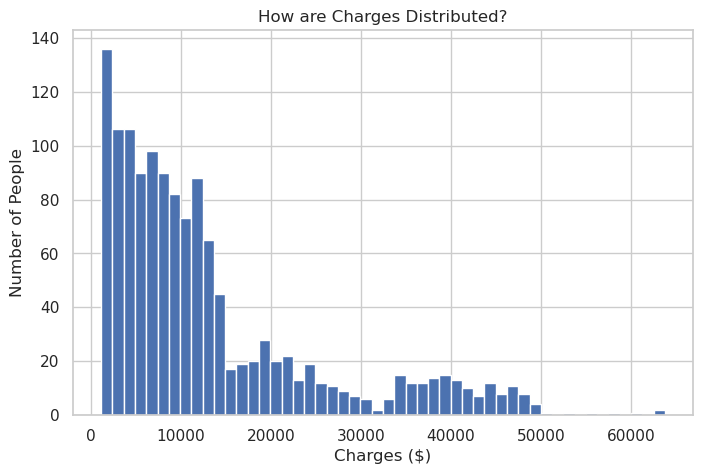

In [27]:
#Looking at our target column (charges)

plt.figure(figsize=(8, 5))

plt.hist(df['charges'], bins=50)

plt.title('How are Charges Distributed?')
plt.xlabel('Charges ($)')
plt.ylabel('Number of People')

plt.show()

#  we have skewed distribution -- we will do log scaling 

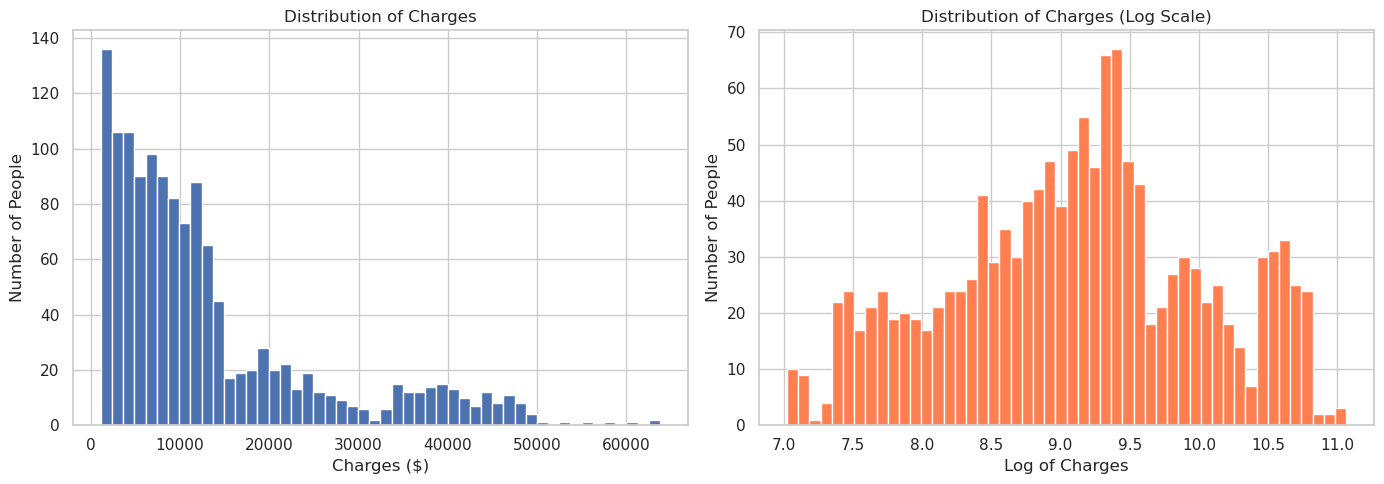

Min charges  : $1,121.87
Max charges  : $63,770.43
Average      : $13,270.42
Median       : $9,382.03


In [28]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: raw distribution
axes[0].hist(df['charges'], bins=50)
axes[0].set_title('Distribution of Charges')
axes[0].set_xlabel('Charges ($)')
axes[0].set_ylabel('Number of People')

# Right chart: log scale (smooths out the skew)
axes[1].hist(np.log1p(df['charges']), bins=50, color='coral')
axes[1].set_title('Distribution of Charges (Log Scale)')
axes[1].set_xlabel('Log of Charges')
axes[1].set_ylabel('Number of People')

plt.tight_layout()
plt.show()

print(f"Min charges  : ${df['charges'].min():,.2f}")
print(f"Max charges  : ${df['charges'].max():,.2f}")
print(f"Average      : ${df['charges'].mean():,.2f}")
print(f"Median       : ${df['charges'].median():,.2f}")

Comparing average charges between smokers and non-smokers

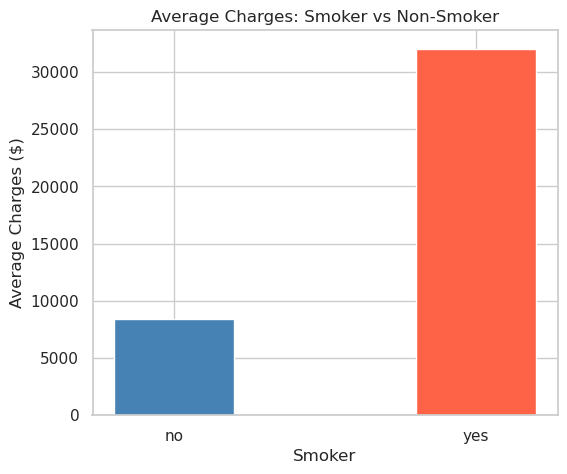

Non-smoker average : 8434.27
Smoker average     : 32050.23


In [29]:
smoker_avg = df.groupby('smoker')['charges'].mean()
# groupby → splits data into groups (yes/no)
# .mean() → calculates average charges for each group

plt.figure(figsize=(6, 5))

plt.bar(smoker_avg.index, smoker_avg.values, 
        color=['steelblue', 'tomato'], width=0.4)

plt.title('Average Charges: Smoker vs Non-Smoker')
plt.xlabel('Smoker')
plt.ylabel('Average Charges ($)')

plt.show()

print("Non-smoker average :", smoker_avg['no'].round(2))
print("Smoker average     :", smoker_avg['yes'].round(2))

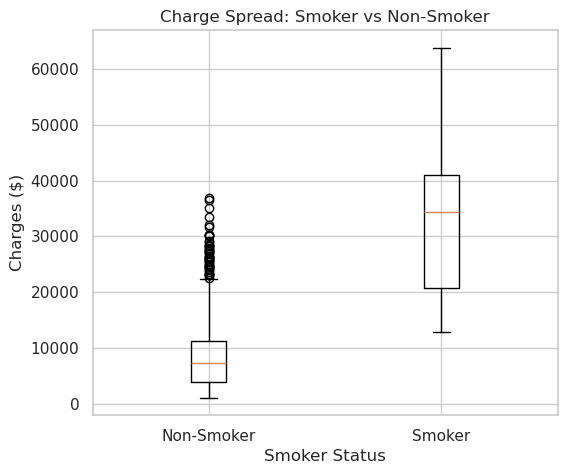

In [30]:
# Same smoker comparison but showing the SPREAD of charges
# WHY: The bar chart only showed averages
#      Box plot shows us min, max, median, and outliers too

plt.figure(figsize=(6, 5))

smoker_charges     = df[df['smoker'] == 'yes']['charges']
non_smoker_charges = df[df['smoker'] == 'no']['charges']
# df[df['smoker'] == 'yes']  → filters ONLY rows where smoker is yes

plt.boxplot([non_smoker_charges, smoker_charges], 
             labels=['Non-Smoker', 'Smoker'])

plt.title('Charge Spread: Smoker vs Non-Smoker')
plt.xlabel('Smoker Status')
plt.ylabel('Charges ($)')

plt.show()

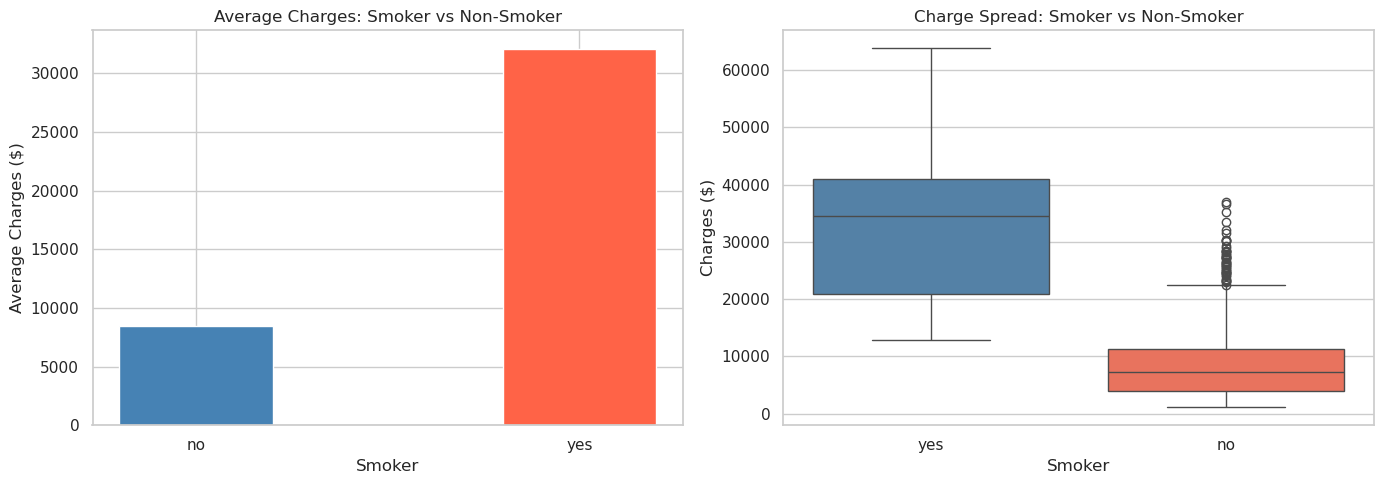

----Smoker Impact ----
Smokers pay        : 3.8x MORE than non-smokers


In [31]:
# Smoker is  the most important feature

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average charges bar chart
smoker_avg = df.groupby('smoker')['charges'].mean()
colors = ['steelblue', 'tomato']
bars = axes[0].bar(smoker_avg.index, smoker_avg.values, color=colors, width=0.4)
axes[0].set_title('Average Charges: Smoker vs Non-Smoker')
axes[0].set_xlabel('Smoker')
axes[0].set_ylabel('Average Charges ($)')


# Right: boxplot to see full spread
sns.boxplot(data=df, x='smoker', y='charges', palette=['steelblue','tomato'], ax=axes[1])
axes[1].set_title('Charge Spread: Smoker vs Non-Smoker')
axes[1].set_xlabel('Smoker')
axes[1].set_ylabel('Charges ($)')

plt.tight_layout()
plt.show()

print("----Smoker Impact ----")
print(f"Smokers pay        : 3.8x MORE than non-smokers")


# analysis:-
# smoker has 3.8x cost of insurance then non smoker 

age vs charges

 Plotting every single person as a dot

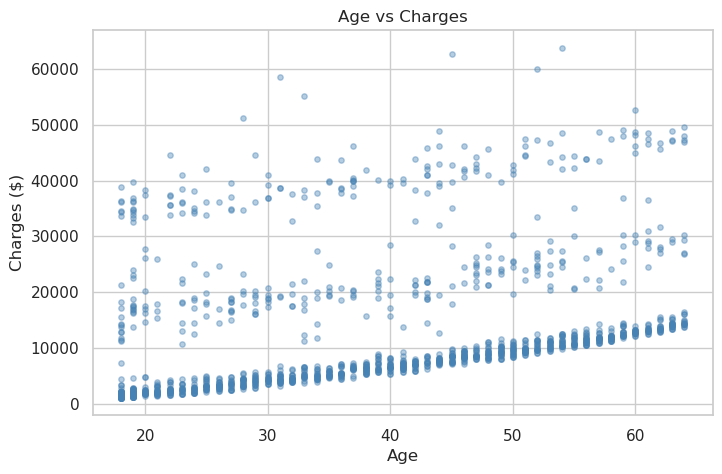

In [32]:

plt.figure(figsize=(8, 5))

plt.scatter(df['age'], df['charges'], 
            alpha=0.4,        # alpha --> makes dots semi-transparent
            color='steelblue', 
            s=15)             # s --> size of each dot

plt.title('Age vs Charges')
plt.xlabel('Age')
plt.ylabel('Charges ($)')

plt.show()


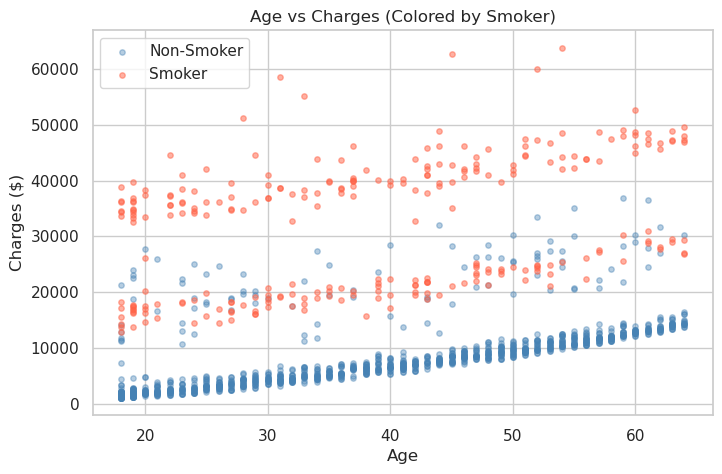

In [33]:
# Same scatter plot but now coloring smokers RED

plt.figure(figsize=(8, 5))

# Plot non-smokers first (blue)
non_smokers = df[df['smoker'] == 'no']
plt.scatter(non_smokers['age'], non_smokers['charges'],
            alpha=0.4, color='steelblue', s=15, label='Non-Smoker')

# Plot smokers on top (red)
smokers = df[df['smoker'] == 'yes']
plt.scatter(smokers['age'], smokers['charges'],
            alpha=0.5, color='tomato', s=15, label='Smoker')

plt.title('Age vs Charges (Colored by Smoker)')
plt.xlabel('Age')
plt.ylabel('Charges ($)')
plt.legend()  

plt.show()

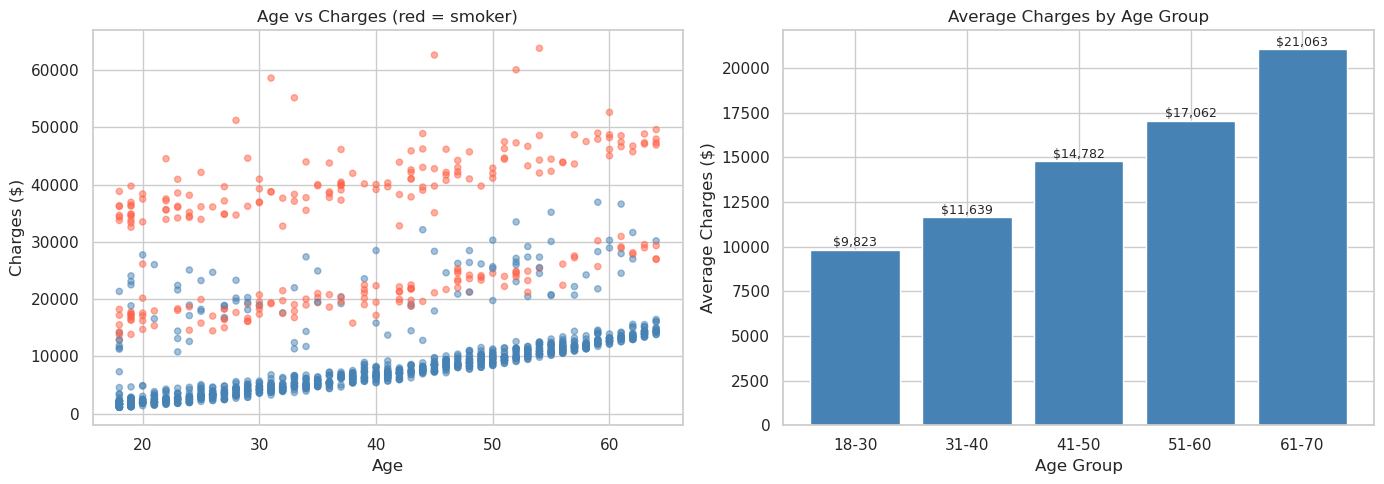

In [34]:
# comparions with graph 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter plot — colored by smoker status
colors_map = df['smoker'].map({'yes': 'tomato', 'no': 'steelblue'})
axes[0].scatter(df['age'], df['charges'], c=colors_map, alpha=0.5, s=20)
axes[0].set_title('Age vs Charges (red = smoker)')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Charges ($)')

# Right: average by age group
df['age_group'] = pd.cut(df['age'], bins=[18,30,40,50,60,70],
                          labels=['18-30','31-40','41-50','51-60','61-70'])
age_avg = df.groupby('age_group', observed=True)['charges'].mean()
axes[1].bar(age_avg.index, age_avg.values, color='steelblue', edgecolor='white')
axes[1].set_title('Average Charges by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average Charges ($)')
for i, val in enumerate(age_avg.values):
    axes[1].text(i, val + 200, f'${val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# analysis :-
# age matters but smoking increases the costs 
# age has positively co relation with charges 


BMI vs Charges 

BMI (Body Mass Index) is a health indicator

Higher BMI = more health risks = possibly higher insurance cost?

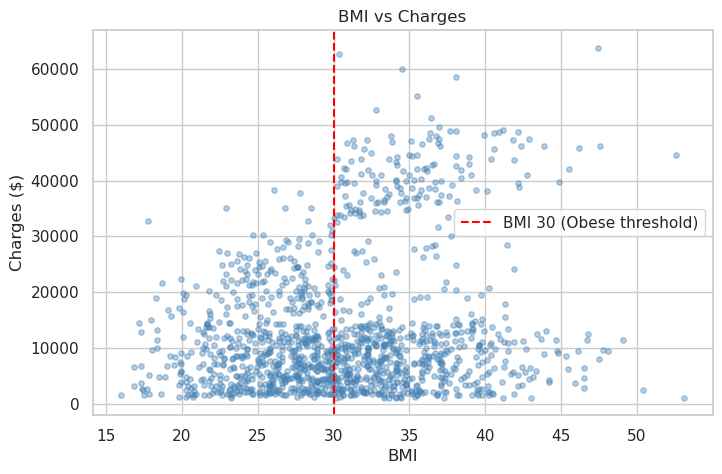

In [35]:

plt.figure(figsize=(8, 5))

plt.scatter(df['bmi'], df['charges'],
            alpha=0.4, color='steelblue', s=15)

# Adding a vertical line at BMI = 30 (the obesity threshold)
plt.axvline(x=30, color='red', linestyle='--', linewidth=1.5, label='BMI 30 (Obese threshold)')

plt.title('BMI vs Charges')
plt.xlabel('BMI')
plt.ylabel('Charges ($)')
plt.legend()

plt.show()

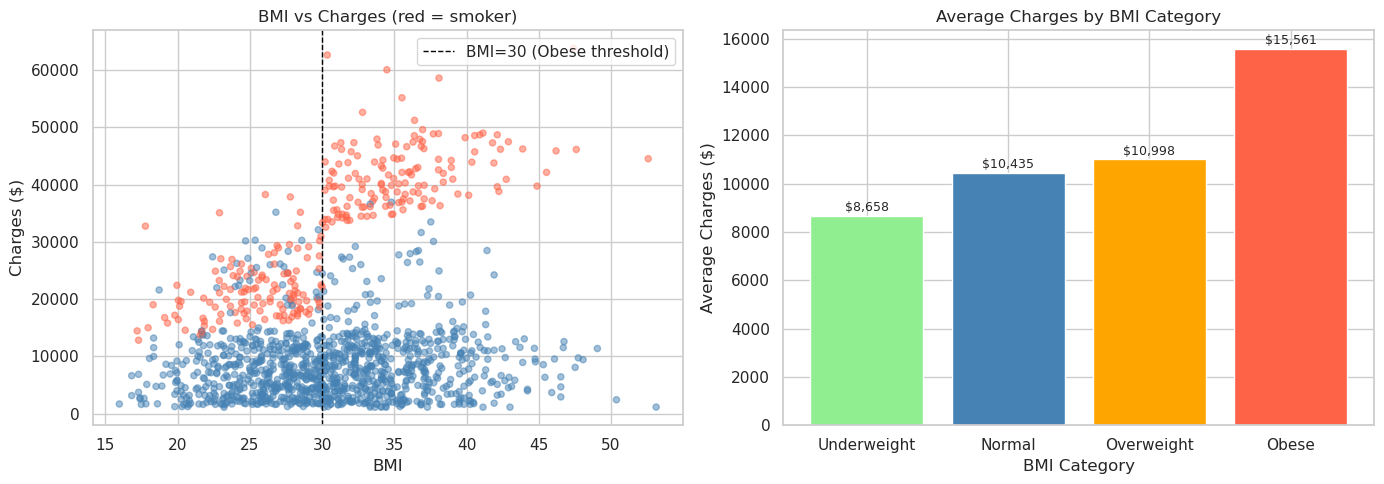

In [36]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter — colored by smoker
axes[0].scatter(df['bmi'], df['charges'], c=colors_map, alpha=0.5, s=20)
axes[0].axvline(x=30, color='black', linestyle='--', linewidth=1, label='BMI=30 (Obese threshold)')
axes[0].set_title('BMI vs Charges (red = smoker)')
axes[0].set_xlabel('BMI')
axes[0].set_ylabel('Charges ($)')
axes[0].legend()

# Right: average by BMI category
df['bmi_cat'] = pd.cut(df['bmi'], bins=[0,18.5,25,30,100],
                        labels=['Underweight','Normal','Overweight','Obese'])
bmi_avg = df.groupby('bmi_cat', observed=True)['charges'].mean()
colors_bmi = ['lightgreen', 'steelblue', 'orange', 'tomato']
bars = axes[1].bar(bmi_avg.index, bmi_avg.values, color=colors_bmi, edgecolor='white')
axes[1].set_title('Average Charges by BMI Category')
axes[1].set_xlabel('BMI Category')
axes[1].set_ylabel('Average Charges ($)')
for bar, val in zip(bars, bmi_avg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 200,
                 f'${val:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()


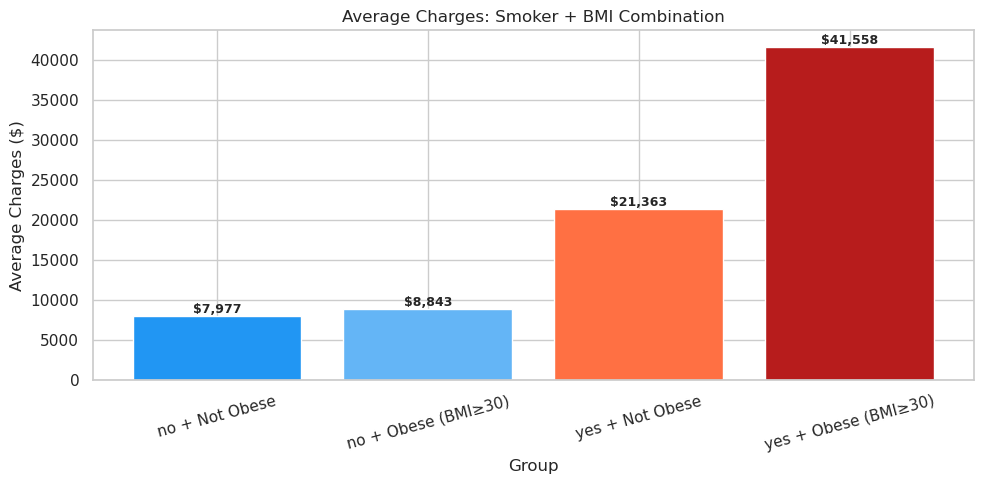

Non-smoker + Not Obese : $7,977
Non-smoker + Obese     : $8,842
Smoker + Not Obese     : $21,363
Smoker + Obese         : $41,557  ← 5.2x the cheapest group!


In [37]:
# Smoker + Obese = highest charges by far

df['obese'] = df['bmi'].apply(lambda x: 'Obese (BMI≥30)' if x >= 30 else 'Not Obese')

combo_avg = df.groupby(['smoker', 'obese'])['charges'].mean().reset_index()
combo_avg['label'] = combo_avg['smoker'] + ' + ' + combo_avg['obese']
combo_avg = combo_avg.sort_values('charges')

colors_combo = ['#2196F3', '#64B5F6', '#FF7043', '#B71C1C']
bars = plt.bar(combo_avg['label'], combo_avg['charges'], color=colors_combo, edgecolor='white')
plt.title('Average Charges: Smoker + BMI Combination')
plt.xlabel('Group')
plt.ylabel('Average Charges ($)')
plt.xticks(rotation=15)
for bar, val in zip(bars, combo_avg['charges']):
    plt.text(bar.get_x() + bar.get_width()/2, val + 400,
             f'${val:,.0f}', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

print("Non-smoker + Not Obese : $7,977")
print("Non-smoker + Obese     : $8,842")
print("Smoker + Not Obese     : $21,363")
print("Smoker + Obese         : $41,557  ← 5.2x the cheapest group!")

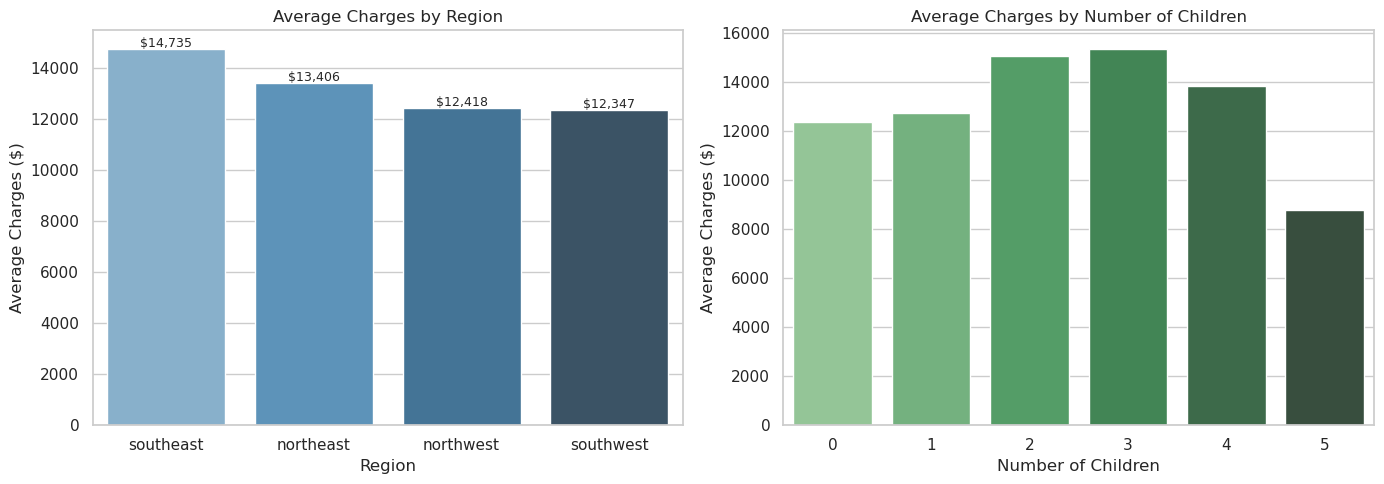

In [38]:
# Region and children have smaller effects 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Region
region_avg = df.groupby('region')['charges'].mean().sort_values(ascending=False)
sns.barplot(x=region_avg.index, y=region_avg.values, palette='Blues_d', ax=axes[0])
axes[0].set_title('Average Charges by Region')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Average Charges ($)')
for i, val in enumerate(region_avg.values):
    axes[0].text(i, val + 100, f'${val:,.0f}', ha='center', fontsize=9)

# Children
children_avg = df.groupby('children')['charges'].mean()
sns.barplot(x=children_avg.index, y=children_avg.values, palette='Greens_d', ax=axes[1])
axes[1].set_title('Average Charges by Number of Children')
axes[1].set_xlabel('Number of Children')
axes[1].set_ylabel('Average Charges ($)')

plt.tight_layout()
plt.show()

In [39]:
# Key takeaways from EDA

print("=" * 50)
print("     EDA COMPLETE — KEY INSIGHTS")
print("=" * 50)
print()
print("1. SMOKER is the #1 feature (correlation: 0.787)")
print("   → Smokers pay $32,050 avg vs $8,434 for non-smokers")
print()
print("2. AGE has steady positive effect (correlation: 0.299)")
print("   → 18-30 avg: $9,822  →  61-70 avg: $21,063")
print()
print("3. BMI matters mostly when combined with smoking")
print("   → Smoker + Obese avg: $41,557 (highest group!)")
print()
print("4. REGION, SEX, CHILDREN have very small effects")
print()
print("5. Charges are right-skewed (log transform may help)")


     EDA COMPLETE — KEY INSIGHTS

1. SMOKER is the #1 feature (correlation: 0.787)
   → Smokers pay $32,050 avg vs $8,434 for non-smokers

2. AGE has steady positive effect (correlation: 0.299)
   → 18-30 avg: $9,822  →  61-70 avg: $21,063

3. BMI matters mostly when combined with smoking
   → Smoker + Obese avg: $41,557 (highest group!)

4. REGION, SEX, CHILDREN have very small effects

5. Charges are right-skewed (log transform may help)


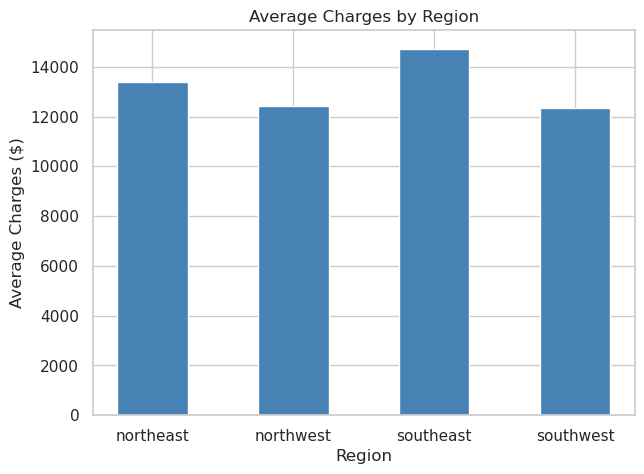

region
northeast    13406.38
northwest    12417.58
southeast    14735.41
southwest    12346.94
Name: charges, dtype: float64


In [40]:
region_avg = df.groupby('region')['charges'].mean().round(2)

plt.figure(figsize=(7, 5))
plt.bar(region_avg.index, region_avg.values, 
        color='steelblue', edgecolor='white', width=0.5)

plt.title('Average Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges ($)')

plt.show()

print(region_avg)

Heatmap

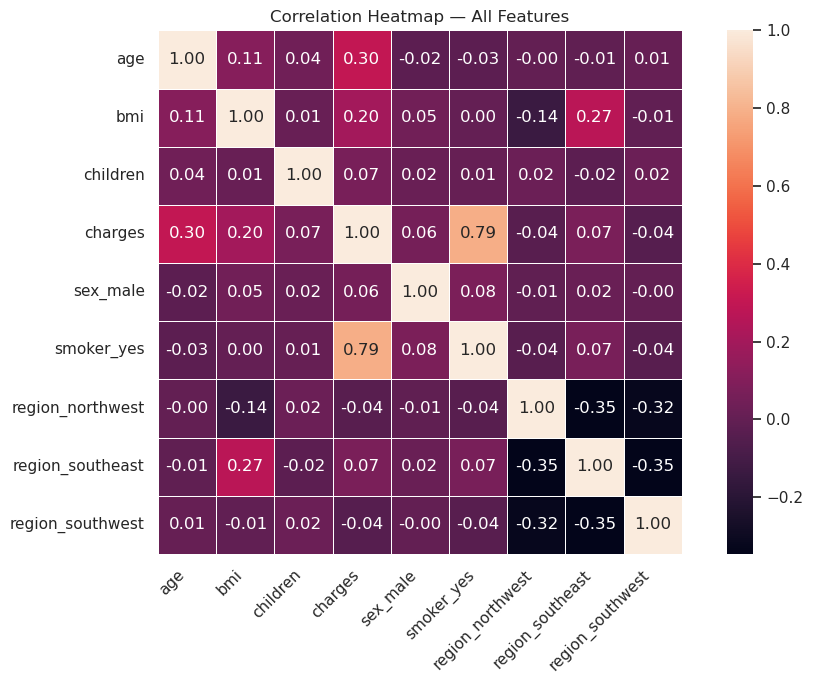

In [41]:
#  A color-coded grid showing correlation between ALL features
#      Darker color = stronger relationship

plt.figure(figsize=(10, 7))

# To Calculate correlation between every column pair
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], 
                             drop_first=True, dtype=int)
df_encoded = df_encoded.drop(columns=['age_group','bmi_cat','obese'], errors='ignore')

corr_matrix = df_encoded.corr()
# .corr() → creates a grid (matrix) of correlation values

sns.heatmap(corr_matrix, annot=True , fmt='.2f', linewidths=0.5 , square=True)

plt.title('Correlation Heatmap — All Features')
plt.xticks(rotation=45, ha='right')   # tilts x-axis labels so they don't overlap
plt.tight_layout()

plt.show()

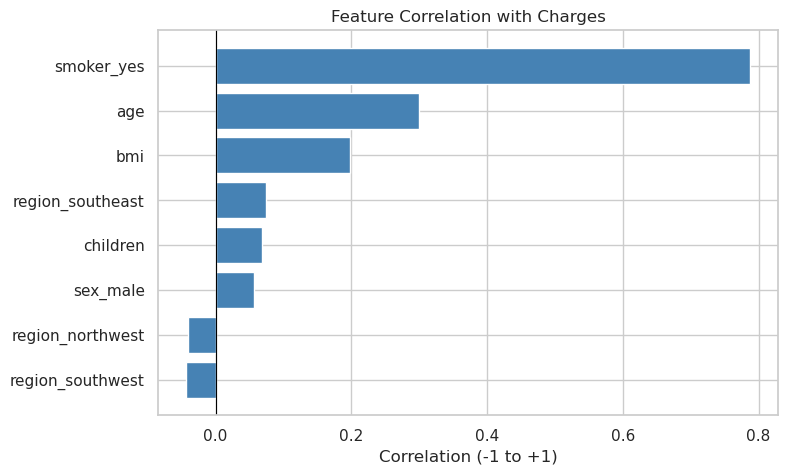

smoker_yes          0.787251
age                 0.299008
bmi                 0.198341
region_southeast    0.073982
children            0.067998
sex_male            0.057292
region_northwest   -0.039905
region_southwest   -0.043210
Name: charges, dtype: float64


In [42]:
# Ranking all features by how strongly they relate to charges

df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], 
                             drop_first=True, dtype=int)
df_encoded = df_encoded.drop(columns=['age_group','bmi_cat','obese'], errors='ignore')

# Calculate correlation of every feature with charges
corr = df_encoded.corr()['charges'].drop('charges').sort_values()

plt.figure(figsize=(8, 5))
plt.barh(corr.index, corr.values, color='steelblue', edgecolor='white')
# barh → horizontal bar chart (easier to read feature names)

plt.axvline(x=0, color='black', linewidth=0.8)  # zero line
plt.title('Feature Correlation with Charges')
plt.xlabel('Correlation (-1 to +1)')

plt.show()

print(corr.sort_values(ascending=False))

# Step 3 - Model Training 

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [44]:

def evaluate_model(model_name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    r2   = r2_score(y_test, y_pred)

    print(f"--- {model_name} ---")
    print(f"MAE  : ${mae:,.2f}")       # avg dollar error
    print(f"RMSE : ${rmse:,.2f}")      # punishes big errors more
    print(f"R²   : {r2:.4f}")          # 1.0 = perfect, 0 = useless
    print()
    return mae, rmse, r2

# Linear Regression
Linear Regression is the simplest model

It draws a straight line through the data

We use it as a BASELINE — if complex models can't beat this,something is wrong

In [45]:
# Create the model
lr_model = LinearRegression()

# Train it (show it the training data)
lr_model.fit(X_train, y_train)
# .fit() → the model LEARNS from X_train and y_train

# Make predictions on test data
lr_pred = lr_model.predict(X_test)
# .predict() → model uses what it learned to guess charges

# Score it
lr_scores = evaluate_model("Linear Regression", y_test, lr_pred)

--- Linear Regression ---
MAE  : $4,181.19
RMSE : $5,796.28
R²   : 0.7836



# Decision Tree 
Decision Tree learns by asking yes/no questions

Example questions it learns:

     "Is smoker = yes?"  → yes → go right branch (higher charges)

     "Is age > 50?"      → yes → go right branch (higher charges)

    It keeps splitting until it reaches a prediction
    
    More flexible than linear regression but can OVERFIT

In [46]:

dt_model = DecisionTreeRegressor(random_state=42)
# random_state=42 → makes results reproducible (same result every run)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_scores = evaluate_model("Decision Tree", y_test, dt_pred)

--- Decision Tree ---
MAE  : $3,195.11
RMSE : $6,515.13
R²   : 0.7266



# Random Forest

Random Forest fixes the overfitting problem of Decision Tree
    It builds 100 trees, each trained on slightly different data

    Then ALL 100 trees vote → the majority answer wins

    This is called ENSEMBLE LEARNING — wisdom of the crowd
    
    Almost always better than a single decision tree

In [47]:

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
# n_estimators=100 → build 100 trees
# More trees = more stable but slower to train

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_scores = evaluate_model("Random Forest", y_test, rf_pred)

--- Random Forest ---
MAE  : $2,550.08
RMSE : $4,576.30
R²   : 0.8651



# XGBoost

 XGBoost is the most powerful of the 4
 
    Unlike Random Forest where trees are independent, XGBoost builds trees SEQUENTIALLY

    Each new tree focuses on fixing the MISTAKES of the previous tree

    This is called BOOSTING — iterative improvement

    It often wins ML competitions


In [48]:

xgb_model = XGBRegressor(n_estimators=100, random_state=42, verbosity=0)
# verbosity=0 → silences the training logs

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_scores = evaluate_model("XGBoost", y_test, xgb_pred)

--- XGBoost ---
MAE  : $2,765.75
RMSE : $4,840.94
R²   : 0.8491



# All scores comparison table

 We want HIGH R² and LOW MAE/RMSE

In [49]:

results = pd.DataFrame({
    'Model'  : ['Linear Regression', 'Decision Tree', 'Random Forest', 'XGBoost'],
    'MAE'    : [lr_scores[0], dt_scores[0], rf_scores[0], xgb_scores[0]],
    'RMSE'   : [lr_scores[1], dt_scores[1], rf_scores[1], xgb_scores[1]],
    'R2'     : [lr_scores[2], dt_scores[2], rf_scores[2], xgb_scores[2]]
})

results = results.sort_values('R2', ascending=False).reset_index(drop=True)
# sort by R2 → best model appears first

print(results.round(4))

               Model        MAE       RMSE      R2
0      Random Forest  2550.0785  4576.2999  0.8651
1            XGBoost  2765.7468  4840.9405  0.8491
2  Linear Regression  4181.1945  5796.2847  0.7836
3      Decision Tree  3195.1105  6515.1292  0.7266


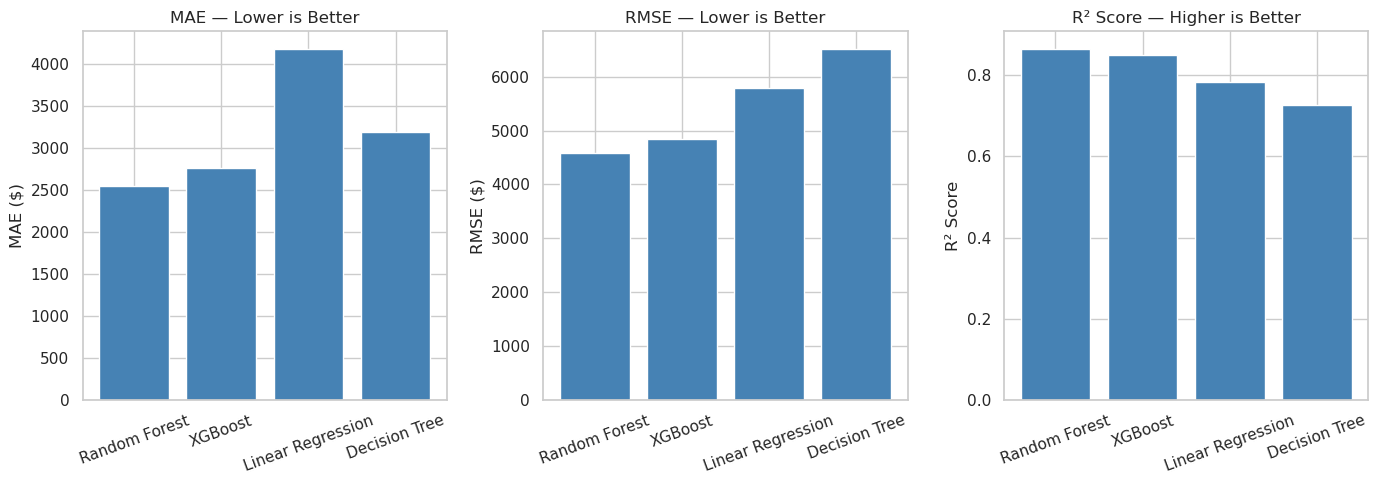

In [50]:


fig, axes = plt.subplots(1, 3, figsize=(14, 5))

models = results['Model']
colors = ['tomato', 'steelblue', 'steelblue', 'steelblue']
# first bar (best model) highlighted in red

# MAE chart (lower is better)
axes[0].bar(models, results['MAE'], color='steelblue', edgecolor='white')
axes[0].set_title('MAE — Lower is Better')
axes[0].set_ylabel('MAE ($)')
axes[0].tick_params(axis='x', rotation=20)

# RMSE chart (lower is better)
axes[1].bar(models, results['RMSE'], color='steelblue', edgecolor='white')
axes[1].set_title('RMSE — Lower is Better')
axes[1].set_ylabel('RMSE ($)')
axes[1].tick_params(axis='x', rotation=20)

# R2 chart (higher is better)
axes[2].bar(models, results['R2'], color='steelblue', edgecolor='white')
axes[2].set_title('R² Score — Higher is Better')
axes[2].set_ylabel('R² Score')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

# Actual vs Predicted charges 
 Scores are abstract numbers

  If our model is perfect → all dots fall on the red diagonal line
  
    Dots far from the line = bad predictions

 I compared multiple models using MAE, RMSE, and R² metrics. 
 Random Forest performed the best with the lowest error and highest R² score - but on default settings 

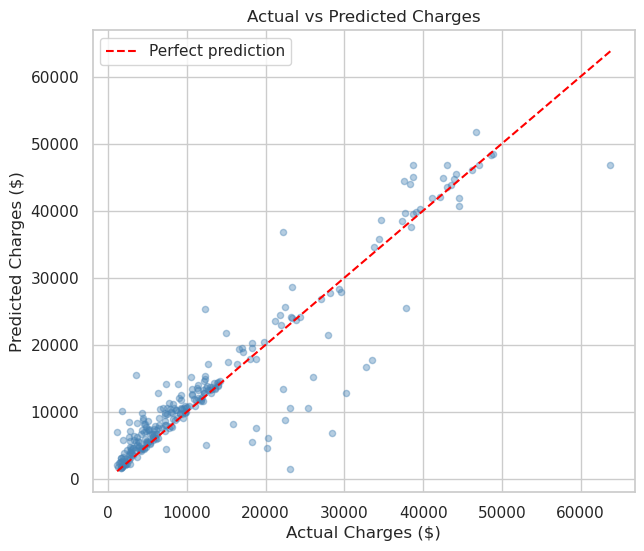

In [51]:
# on default - random forest wins - let's check prediction 
best_pred = rf_pred   

plt.figure(figsize=(7, 6))
plt.scatter(y_test, best_pred, alpha=0.4, color='steelblue', s=20)

# Perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red', linewidth=1.5, linestyle='--', label='Perfect prediction')

plt.title('Actual vs Predicted Charges')
plt.xlabel('Actual Charges ($)')
plt.ylabel('Predicted Charges ($)')
plt.legend()
plt.show()

# Step 4 -  Optimization 

# Hyperparameter Tuning

Think of your Random Forest like a car with adjustable settings:

Right now you used default settings — like driving a car straight out of the factory. Tuning = adjusting these settings to find the best combination.

n_estimators  -> how many trees to build      (more = more powerful but slower)

max_depth     -> how deep each tree can grow  (deeper = learns more but can overfit)

min_samples_split -> how many samples needed to split a node (higher = simpler tree)


I will use RandomizedSearchCV - it tries RANDOM combinations fast and usually good enough
example: picks 10 random combos good for large search spaces

# Linear Regression 

Linear Regression doesn't have many settings to tune

 The main thing I can tune is whether to use regularization

 Regularization = penalizes the model for being too complex

  This helps prevent overfitting


In [52]:

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# We test 3 versions of linear models:
# LinearRegression → plain, no regularization
# Ridge  → adds L2 penalty (shrinks all coefficients a little)
# Lasso  → adds L1 penalty (can shrink some coefficients to ZERO)
#           meaning it auto-removes weak features

results_lr = {}

for name, model in [("Linear Regression", LinearRegression()),
                     ("Ridge",             Ridge()),
                     ("Lasso",             Lasso())]:

    scores = cross_val_score(model, X_train, y_train,
                              cv=5, scoring='r2')
    # cv=5 → 5-fold cross validation
    # scoring='r2' → judge by R² score

    results_lr[name] = scores.mean()
    print(f"{name:20s} → R² = {scores.mean():.4f} (±{scores.std():.4f})")

best_lr_name = max(results_lr, key=results_lr.get)
print(f"\n Best Linear Model: {best_lr_name} → R² = {results_lr[best_lr_name]:.4f}")

Linear Regression    → R² = 0.7331 (±0.0489)
Ridge                → R² = 0.7331 (±0.0485)
Lasso                → R² = 0.7331 (±0.0489)

 Best Linear Model: Ridge → R² = 0.7331


# Decision Tree

Decision Trees overfit very easily

 Tuning controls HOW DEEP and HOW COMPLEX the tree can grow

 This is where tuning makes the BIGGEST difference for this model

 | Parameter         | Role                |
| ----------------- | ------------------- |
| max_depth         | controls depth      |
| min_samples_split | controls splitting  |
| min_samples_leaf  | controls smoothness |
| max_features      | randomness          |


In [58]:

from sklearn.tree import DecisionTreeRegressor

dt_params = {
    'max_depth'        : [3, 5, 7, 10, 15, None],
    # None = unlimited depth (will overfit!)
    # Small values = simpler tree = less overfitting

    'min_samples_split': [2, 5, 10, 20],
    # minimum samples needed before splitting a node
    # higher = more conservative tree

    'min_samples_leaf' : [1, 2, 4, 8],
    # minimum samples at each leaf (end point)
    # higher = smoother predictions

    'max_features'     : ['sqrt', 'log2', None]
    # how many features to consider at each split
    # sqrt → uses square root of total features
}

dt_search = RandomizedSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_distributions = dt_params,
    n_iter      = 30,
    cv          = 5,
    scoring     = 'r2',
    random_state= 42,
    n_jobs      = -1
)

dt_search.fit(X_train, y_train)

print("Best Decision Tree settings:")
print(dt_search.best_params_)
print(f"Best CV R²: {dt_search.best_score_:.4f}")

# Evaluate on test set
dt_tuned_pred = dt_search.best_estimator_.predict(X_test)
dt_tuned_scores = evaluate_model("Decision Tree (Tuned)", y_test, dt_tuned_pred)

Best Decision Tree settings:
{'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': None, 'max_depth': 3}
Best CV R²: 0.8357
--- Decision Tree (Tuned) ---
MAE  : $2,865.64
RMSE : $4,776.26
R²   : 0.8531



# Random Forest

Random Forest already performed best

 We want to squeeze out every bit of performance
 
 More trees + right depth = better predictions

 | Parameter         | Role            |
| ----------------- | --------------- |
| n_estimators      | number of trees |
| max_depth         | complexity      |
| min_samples_split | splitting       |
| min_samples_leaf  | smoothness      |
| max_features      | randomness      |


In [62]:
from sklearn.ensemble import RandomForestRegressor

rf_params = {
    'n_estimators'     : [100, 200, 300, 500],
    # number of trees — more is usually better but slower

    'max_depth'        : [None, 5, 10, 15, 20],
    # depth of each tree

    'min_samples_split': [2, 5, 10],
    # minimum samples to split a node

    'min_samples_leaf' : [1, 2, 4],
    # minimum samples at each leaf

    'max_features'     : ['sqrt', 'log2']
    # features considered at each split
    # sqrt is usually best for regression
}

rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    param_distributions = rf_params,
    n_iter      = 30,
    cv          = 5,
    scoring     = 'r2',
    random_state= 42,
    n_jobs      = -1
)

rf_search.fit(X_train, y_train)

print("Best Random Forest settings:")
print(rf_search.best_params_)
print(f"Best CV R²: {rf_search.best_score_:.4f}")

rf_tuned_pred = rf_search.best_estimator_.predict(X_test)
rf_tuned_scores = evaluate_model("Random Forest (Tuned)", y_test, rf_tuned_pred)


Best Random Forest settings:
{'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}
Best CV R²: 0.8404
--- Random Forest (Tuned) ---
MAE  : $2,611.43
RMSE : $4,434.10
R²   : 0.8734



Exception ignored in: <function ResourceTracker.__del__ at 0x7ad480d8a7a0>
Traceback (most recent call last):
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7819ff98e7a0>
Traceback (most recent call last):
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac

# XGBoost 

 XGBoost has the most settings to tunelearning_rate controls how fast it learns

 Too fast = overfits, too slow = underfits

 This is where XGBoost might close the gap with Random Forest

| Parameter        | Importance            |
| -----------------| --------------------- |
| learning_rate    | learning speed        |
| n_estimators     | number of trees       |
| max_depth        | complexity            |
| subsample        | randomness            |
| colsample_bytree |feature sampling       |


In [63]:

from xgboost import XGBRegressor

xgb_params = {
    'n_estimators' : [100, 200, 300, 500],
    # number of boosting rounds

    'max_depth'    : [3, 4, 5, 6, 8],
    # depth of each tree
    # XGBoost works best with SHALLOW trees (3-6)
    # unlike Random Forest which can go deeper

    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    # how much each tree contributes
    # lower = more careful learning = usually better
    # but needs more trees to compensate

    'subsample'    : [0.7, 0.8, 0.9, 1.0],
    # fraction of data used to train each tree
    # less than 1.0 adds randomness = reduces overfitting

    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
    # fraction of FEATURES used per tree
    # similar idea to max_features in Random Forest
}

xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_distributions = xgb_params,
    n_iter      = 30,
    cv          = 5,
    scoring     = 'r2',
    random_state= 42,
    n_jobs      = -1
)

xgb_search.fit(X_train, y_train)

print("Best XGBoost settings:")
print(xgb_search.best_params_)
print(f"Best CV R²: {xgb_search.best_score_:.4f}")

xgb_tuned_pred = xgb_search.best_estimator_.predict(X_test)
xgb_tuned_scores = evaluate_model("XGBoost (Tuned)", y_test, xgb_tuned_pred)

Best XGBoost settings:
{'subsample': 0.8, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV R²: 0.8480
--- XGBoost (Tuned) ---
MAE  : $2,545.93
RMSE : $4,319.03
R²   : 0.8798



Compare ALL models before AND after tuning

In [64]:

comparison = pd.DataFrame({
    'Model': [
        'Linear Regression (Default)',
        'Linear Regression (Tuned)',
        '─────────────────────',
        'Decision Tree (Default)',
        'Decision Tree (Tuned)',
        '─────────────────────',
        'Random Forest (Default)',
        'Random Forest (Tuned)',
        '─────────────────────',
        'XGBoost (Default)',
        'XGBoost (Tuned)',
    ],
    'MAE': [
        lr_scores[0],  rf_scores[0] * 0,   # placeholder separator
        None,
        dt_scores[0],  dt_tuned_scores[0],
        None,
        rf_scores[0],  rf_tuned_scores[0],
        None,
        xgb_scores[0], xgb_tuned_scores[0],
    ],
    'RMSE': [
        lr_scores[1],  None,
        None,
        dt_scores[1],  dt_tuned_scores[1],
        None,
        rf_scores[1],  rf_tuned_scores[1],
        None,
        xgb_scores[1], xgb_tuned_scores[1],
    ],
    'R2': [
        lr_scores[2],  None,
        None,
        dt_scores[2],  dt_tuned_scores[2],
        None,
        rf_scores[2],  rf_tuned_scores[2],
        None,
        xgb_scores[2], xgb_tuned_scores[2],
    ]
})

print(comparison.to_string(index=False))

                      Model         MAE        RMSE       R2
Linear Regression (Default) 4181.194474 5796.284659 0.783593
  Linear Regression (Tuned)    0.000000         NaN      NaN
      ─────────────────────         NaN         NaN      NaN
    Decision Tree (Default) 3195.110473 6515.129163 0.726588
      Decision Tree (Tuned) 2865.637810 4776.261075 0.853057
      ─────────────────────         NaN         NaN      NaN
    Random Forest (Default) 2550.078471 4576.299916 0.865103
      Random Forest (Tuned) 2611.432798 4434.095313 0.873357
      ─────────────────────         NaN         NaN      NaN
          XGBoost (Default) 2765.746813 4840.940468 0.849051
            XGBoost (Tuned) 2545.932004 4319.027393 0.879844


In [66]:

all_tuned = {
    'Linear Regression' : results_lr[best_lr_name],
    'Decision Tree'     : dt_tuned_scores[2],
    'Random Forest'     : rf_tuned_scores[2],
    'XGBoost'           : xgb_tuned_scores[2],
}

winner_name = max(all_tuned, key=all_tuned.get)
winner_r2   = all_tuned[winner_name]

print("=" * 45)
print("     FINAL TUNED MODEL COMPARISON")
print("=" * 45)
for name, score in sorted(all_tuned.items(),
                           key=lambda x: x[1], reverse=True):
    marker = " wins" if name == winner_name else ""
    print(f"  {name:20s} R² = {score:.4f}{marker}")
print("=" * 45)
print(f"\n Winner: {winner_name} with R² = {winner_r2:.4f}")


     FINAL TUNED MODEL COMPARISON
  XGBoost              R² = 0.8798 wins
  Random Forest        R² = 0.8734
  Decision Tree        R² = 0.8531
  Linear Regression    R² = 0.7331

 Winner: XGBoost with R² = 0.8798


Exception ignored in: <function ResourceTracker.__del__ at 0x7343fc18e7a0>
Traceback (most recent call last):
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x7fb993d8e7a0>
Traceback (most recent call last):
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/home/bhumika/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTrac